## 指令微调介绍

大语言模型的预训练是通过让模型学会逐个生成单词来实现的。预训练后的大语言模型能够进行文本补全，这意味着给定任意一个片段作为输入，模型能够生成一个句子或撰写一个段落。

然而，预训练后的大语言模型在执行特定指令时往往表现不佳，比如无法完成像“纠正这段文字的语法”或“将这段话变成被动语态”这样的指令。在本章我们将专注于提高大语言模型遵循指令并生成合理回复的能力

![instructionAbility](imgs/instructionAbility.png)

## 准备数据集

In [20]:
import json
import os
import requests

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data

file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


### 数据处理

![dataProcess](imgs/dataProcess.png)

首先第一步，对数据集进行文本格式化

In [21]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)


model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


然后第二步，将格式化后的文本数据集词元化，从而生成模型能够处理的词元ID序列

In [22]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        self.encoded_texts = []
        for entry in data:
            # 文本格式化
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            # 词元化
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

接着第三步，为了将多个训练示例聚合到一个批次中来加速训练，需要将所有输入词元填充到相似的长度。我们使用<|endoftext|>作为填充词元。

In [23]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [24]:
import torch
def custom_collate_draft_1(batch,pad_token_id=50256,device="cpu"):
    batch_max_length = max(len(item) for item in batch)
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs_lst.append(torch.tensor(padded))

    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

# 测试
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


第四步，创建目标词元ID用于训练，对每个输入序列而言，首先将其向左移动一个词元的位置，然后将输入序列的第一个词元忽略，最后在尾部加入结束符词元即可得到其对应的目标序列

In [25]:
def custom_collate_draft_2(batch,pad_token_id=50256,device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  
        targets = torch.tensor(padded[1:])  
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

# 测试
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


最后，用占位符替换部分填充词元，使模型在学习时不计算这部分损失

我们会为所有填充词元都分配一个-100占位符值​。这个特殊值使我们能够在计算训练损失时排除填充词元的影响，从而确保只有有效的数据会影响模型的学习。

In [26]:
def custom_collate_fn(batch,pad_token_id=50256,ignore_index=-100,
    allowed_max_length=None,device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch)

    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  
        targets = torch.tensor(padded[1:])  

        # New: Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # New: Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

# 测试
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


在创建目标序列的过程中，我们将输入词元序列向左移动一个位置并附加一个结束符词元。同时，我们将结束符（填充）词元替换为占位符值(-100)

不过，值得注意的是，我们在目标列表中保留了一个结束符词元，ID为50256。保留此词元有助于大语言模型学会何时根据指令生成结束符词元，一般我们将其作为生成的回复已经完成的指示符。

为什么要将多余的结束符词元50256全部替换为占位符值-100呢？

为方便理解，可以考虑一个简单的示例，其中输出逻辑值(logits)的每一维都对应着模型词汇表中的一个潜在词元。下面的代码展示了在训练过程中交叉熵损失（参见第5章）是如何计算的，这一过程与我们在预训练和分类微调模型时的操作类似

In [27]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],  
     [-0.5, 1.5]]  
)
targets_1 = torch.tensor([0, 1])


loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


上述代码计算得到的损失值是1.1269，但如果我们增加一个额外的词元会影响损失的计算：

In [28]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


在加入第三个词元后，损失值变成了0.7936。

到目前为止，我们已经使用PyTorch的交叉熵损失函数进行了若干简单示例计算，这个损失函数正是我们在预训练和分类微调时使用的损失函数。接下来，来看一个有趣的情况：如果将第三个目标词元ID替换为-100，会发生什么呢？

In [29]:
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


得到的损失与之前示例计算中的损失相同。换言之，此时交叉熵损失函数忽略了targets_3向量中的第三项(-100)所对应的损失

那么，-100究竟有什么特别之处，使交叉熵损失能够忽略它呢？原来，在PyTorch中，交叉熵函数的默认设置为cross_entropy(..., ignore_index=-100)。这意味着它会忽略标记为-100的目标。我们利用这个ignore_index来忽略那些用于填充训练示例以使每个批次具有相同长度的额外结束符（填充）词元。然而，我们需要在目标中保留结束符词元ID50256，因为它有助于大语言模型学习生成结束符词元，从而在适当的时候结束回复。

## 创建数据加载器

到目前为止，我们已经准备好数据集，并实现了一个自定义的聚合函数来对指令数据集进行分批处理。现在，我们可以开始创建训练集、验证集和测试集，并使用数据加载器加载它们来完成大语言模型的指令微调与评估

在创建数据加载器之前，还需要讨论一下custom_collate_fn的设备设置。该函数包含将输入和目标张量（如torch.stack(inputs_lst).to(device)）移动到指定设备的代码，这个设备既可以是"cpu"或"cuda"（适用于NVIDIA GPU）​，也可以是"mps"（适用于配备Apple Silicon芯片的Mac）​。

In [30]:
import torch

# ========== 1. 检测可用设备并指定GPU编号 ==========
if torch.cuda.is_available():
    # 指定使用第几张GPU（例如 gpu:0, gpu:1）
    gpu_id = 3  # ← 改成你想用的显卡编号
    
    # 检查指定的GPU是否存在
    if gpu_id >= torch.cuda.device_count():
        print(f"警告：GPU {gpu_id} 不存在，共有 {torch.cuda.device_count()} 张GPU")
        gpu_id = 0
    
    device = torch.device(f"cuda:{gpu_id}")
    
    # 设置当前进程可见的GPU（可选，防止程序占用其他卡）
    torch.cuda.set_device(gpu_id)
    
elif torch.backends.mps.is_available():
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

# ========== 2. 显示当前正在使用的GPU详细信息 ==========
if device.type == "cuda":
    # 当前使用的GPU编号和名称
    current_gpu = torch.cuda.current_device()
    gpu_name = torch.cuda.get_device_name(current_gpu)
    
    print(f"\n当前使用的GPU: cuda:{current_gpu}")
    print(f"GPU名称: {gpu_name}")
    print(f"显存总量: {torch.cuda.get_device_properties(current_gpu).total_memory / 1024**3:.2f} GB")
    
    # 显示所有可用的GPU
    print(f"\n系统中所有可用的GPU ({torch.cuda.device_count()} 张):")
    for i in range(torch.cuda.device_count()):
        name = torch.cuda.get_device_name(i)
        is_current = " ← 当前使用" if i == current_gpu else ""
        print(f"  cuda:{i} - {name}{is_current}")
    
    # 显存占用情况
    print(f"\n显存使用情况:")
    print(f"  已分配: {torch.cuda.memory_allocated(current_gpu) / 1024**2:.2f} MB")
    print(f"  保留缓存: {torch.cuda.memory_reserved(current_gpu) / 1024**2:.2f} MB")

Device: cuda:3

当前使用的GPU: cuda:3
GPU名称: NVIDIA GeForce RTX 3090
显存总量: 23.57 GB

系统中所有可用的GPU (4 张):
  cuda:0 - NVIDIA GeForce RTX 3090
  cuda:1 - NVIDIA GeForce RTX 3090
  cuda:2 - NVIDIA GeForce RTX 3090
  cuda:3 - NVIDIA GeForce RTX 3090 ← 当前使用

显存使用情况:
  已分配: 0.00 MB
  保留缓存: 0.00 MB


为了在将custom_collate_fn函数应用于PyTorch DataLoader类时重用所选择的设备设置，我们利用Python的functools标准库中的partial函数创建该函数的新版本并预先填充设备参数。此外，可以将allowed_max_length设置为1024，这样数据就会被截断到GPT-2模型支持的最大上下文长度，稍后我们将对其进行微调

In [31]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)


接下来，我们设置数据加载器，并使用自定义的聚合函数来做批处理，我们先对数据进行划分，然后再加载数据加载器

In [32]:
train_portion = int(len(data) * 0.85)  # 85% 训练
test_portion = int(len(data) * 0.1)    # 10% 测试
val_portion = len(data) - train_portion - test_portion  # 剩余5%用于验证

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))


Training set length: 935
Validation set length: 55
Test set length: 110


In [33]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8
torch.manual_seed(123)
# 创建数据集
train_dataset = InstructionDataset(train_data, tokenizer)
# 创建数据加载器
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

In [34]:
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [35]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

该输出表明，第一个输入批次和目标批次的维度为8×61，其中8是批次大小，61是该批次中每个训练样本的词元数量。第二个输入批次和目标批次中的词元数量则有76个，与第一个不同。由于我们使用了自定义的聚合函数，因此数据加载器能够创建不同长度的批次。

## 加载预训练大模型
在数据集准备好之后，大语言模型的指令微调过程从加载预训练大语言模型的权重开始

与之前章节不同的是，我们不再使用参数量为1.24亿的最小的GPT模型，而是加载参数量为3.55亿的中等规模的GPT模型。这是因为参数量为1.24亿的模型容量过于有限，无法通过指令微调获得令人满意的结果。具体来说，较小的模型在学习高质量的指令遵循任务时，缺乏执行该任务所需的复杂模式和细微行为的能力

使用国内hugging-face下载模型文件

In [36]:
"""
#!/bin/bash

# 定义下载目录
DIRNAME="gpt2/355M"
mkdir -p ${DIRNAME}

# 基础地址（镜像站）
BASE="https://hf-mirror.com/openai-community/gpt2-medium/resolve/main"

# 批量下载所有文件到指定文件夹
wget -P ${DIRNAME} ${BASE}/config.json
wget -P ${DIRNAME} ${BASE}/pytorch_model.bin
wget -P ${DIRNAME} ${BASE}/vocab.json
wget -P ${DIRNAME} ${BASE}/merges.txt
wget -P ${DIRNAME} ${BASE}/tokenizer_config.json

echo "✅ GPT2-medium 模型下载完成！路径：$DIRNAME"

"""

'\n#!/bin/bash\n\n# 定义下载目录\nDIRNAME="gpt2/355M"\nmkdir -p ${DIRNAME}\n\n# 基础地址（镜像站）\nBASE="https://hf-mirror.com/openai-community/gpt2-medium/resolve/main"\n\n# 批量下载所有文件到指定文件夹\nwget -P ${DIRNAME} ${BASE}/config.json\nwget -P ${DIRNAME} ${BASE}/pytorch_model.bin\nwget -P ${DIRNAME} ${BASE}/vocab.json\nwget -P ${DIRNAME} ${BASE}/merges.txt\nwget -P ${DIRNAME} ${BASE}/tokenizer_config.json\n\necho "✅ GPT2-medium 模型下载完成！路径：$DIRNAME"\n\n'

加载模型权重并检查

In [37]:
import sys
import os
# 获取当前文件的目录
root_dir = os.path.dirname(os.path.abspath("."))  
# 把根目录加入 sys.path
sys.path.append(root_dir)

from ch04.GPTModel import GPTModel
from ch05.modelUtils import load_hf_weights_into_custom_gpt

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

model = GPTModel(BASE_CONFIG)
weights_path = f"gpt2/355M/pytorch_model.bin"
hf_weights = torch.load(weights_path, map_location=device)

# 先检查实际 key
print("前 20 个 key:")
for i, key in enumerate(hf_weights.keys()):
    print(key)
    if i >= 19:
        break

# 检查关键权重 shape
def find_key(weights, suffix):
    for k in weights.keys():
        if k == suffix or k.endswith("." + suffix):
            return k
    raise KeyError(f"找不到以 {suffix} 结尾的 key")
for suffix in [
    "h.0.attn.c_attn.weight",
    "h.0.attn.c_proj.weight",
    "h.0.mlp.c_fc.weight",
    "h.0.mlp.c_proj.weight",
]:
    real_key = find_key(hf_weights, suffix)
    print(real_key, hf_weights[real_key].shape)

前 20 个 key:
wte.weight
wpe.weight
h.0.ln_1.weight
h.0.ln_1.bias
h.0.attn.bias
h.0.attn.c_attn.weight
h.0.attn.c_attn.bias
h.0.attn.c_proj.weight
h.0.attn.c_proj.bias
h.0.ln_2.weight
h.0.ln_2.bias
h.0.mlp.c_fc.weight
h.0.mlp.c_fc.bias
h.0.mlp.c_proj.weight
h.0.mlp.c_proj.bias
h.1.ln_1.weight
h.1.ln_1.bias
h.1.attn.bias
h.1.attn.c_attn.weight
h.1.attn.c_attn.bias
h.0.attn.c_attn.weight torch.Size([1024, 3072])
h.0.attn.c_proj.weight torch.Size([1024, 1024])
h.0.mlp.c_fc.weight torch.Size([1024, 4096])
h.0.mlp.c_proj.weight torch.Size([4096, 1024])


最后将openai的模型权重更新到我们的模型中

In [38]:
load_hf_weights_into_custom_gpt(model, hf_weights, BASE_CONFIG)
model.eval()

HF 权重加载完成: 24 层, emb_dim=1024


GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MutilHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MutilHeadAttention(
        (W_query): Linear(i

现在，让我们先花一些时间，通过将模型输出与预期的回复进行比较，来评估预训练的大语言模型在验证任务上的表现。这将为我们提供一个模型的基准性能指标，该指标反映了模型在未经微调的情况下在指令遵循任务中的表现情况，并能帮助我们更好地理解微调后的效果。下面我们将使用验证集中第一个样本进行评估

In [39]:
torch.manual_seed(123)

input_text = format_input(val_data[0])
# input_text = format_input(val_data[0]) + "\n\n### Response:\n"
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


接下来，使用generate函数生成模型的回复

In [40]:
from ch05.modelUtils import generate,text_to_token_ids,token_ids_to_text
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)
print(generated_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


generate函数返回的是拼接在一起的输入和输出文本。这种返回值在之前的章节中非常有用，因为未经微调的大语言模型主要用来做文本补全，而将文本补全的输入和输出连接在一起便会形成连贯易读的文本。然而，当评估模型在特定任务上的表现时，我们通常希望仅关注模型生成的回复

为了抽取模型的回复，需要在生成的文本generated_text中减去输入指令的长度

In [41]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


上述输出显示，预训练模型还不能正确遵循给定的指令。尽管它“有模有样”地生成了回复部分### Response，但只是简单地重复了输入的句子和部分指令，未能按照要求将主动句转换为被动句。因此，我们需要实施微调过程，以提升模型理解和正确回复此类请求的能力

## 在指令数据上微调大语言模型
接下来我们将利用上节中加载的预训练模型，并进一步使用本章早期准备的指令数据集对其进行训练。

In [42]:
from ch05.modelUtils import calc_loss_loader,train_model_simple
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.8259100914001465
Validation loss: 3.7619341373443604


初始损失值如上所示，和前面一样，我们的目标是最小化损失

在准备好模型和数据加载器后，现在可以开始训练模型了。下述代码设置了训练过程，包括初始化优化器、设定训练轮数、定义评估的频率和起始上下文(start_context)。在这里，起始上下文是指在训练过程中，评估大语言模型在7.5节中介绍的第一个验证集指令(val_data[0])上生成的回复。

In [43]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)
num_epochs = 2
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.638, Val loss 2.627
Ep 1 (Step 000005): Train loss 1.175, Val loss 1.103
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.945
Ep 1 (Step 000015): Train loss 0.857, Val loss 0.907
Ep 1 (Step 000020): Train loss 0.777, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.754, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.800, Val loss 0.837
Ep 1 (Step 000035): Train loss 0.714, Val loss 0.809
Ep 1 (Step 000040): Train loss 0.674, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.634, Val loss 0.790
Ep 1 (Step 000050): Train loss 0.663, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.761, Val loss 0.764
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.744
Ep 1 (Step 000065): Train loss 0.653, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.536, Val loss 0.733
Ep 1 (Step 000075): Train loss 0.568, Val loss 0.739
Ep 1 (Step 000080): Train loss 0.604, Val loss 0.733
Ep 1 (Step 000085): Train loss 0.515, Val loss 0.717
Ep 1 (Step 000090): Train loss 0.573, Val loss

训练输出日志表明模型正在快速学习，因为在两轮内训练集和验证集的损失值持续下降，这表明模型逐渐提高了理解和遵循所给指令的能力。​（由于模型在两轮内的损失已经降到较低的水平，因此延长训练到第三轮或更多轮并无必要，甚至可能适得其反，导致过拟合加剧。​）

现在，让我们查看训练集损失曲线和验证集损失曲线，以便深入了解模型的学习过程。为此，我们将使用与预训练阶段相同的plot_losses函数。

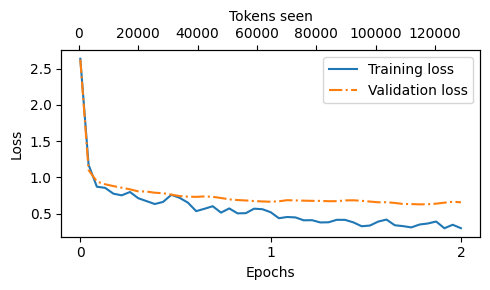

In [44]:
from ch05.modelUtils import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

从损失图中可以看出，模型在训练集和验证集上的表现随着训练进行得到了显著改善。在初期阶段，损失的快速下降表明模型迅速从数据中捕捉到有意义的模式和特征。随着训练进入第二轮，损失虽然继续下降，但下降的速度有所放缓。这表明模型正在微调已经学习的特征，并逐渐收敛到一种稳定的解决方案。

虽然损失图显示出模型正在有效地进行训练，但对模型来说最关键的还是其在回复质量和准确性方面的表现。因此，接下来我们将提取回复，并以一种可以评估和量化质量的格式存储模型的回复。

## 抽取并保存模型回复

我们已经在指令数据集的训练集上完成了对大语言模型的微调，现在要在模型未见过的测试集上评估模型的性能。首先，提取测试集中每个输入对应的模型生成的回复，并将这些回复收集起来进行人工分析。然后，对大语言模型进行评估以量化模型回复的质量。

### 人工评估
为完成回复指令的步骤，可以使用generate函数。接下来，将模型的回复与测试集前面3个条目的预期回复并排打印，以便进行比较。

In [46]:
torch.manual_seed(123)
# 显示进度条，直观看到处理进度（当前第几条/总共几条、预计剩余时间）
for entry in test_data[:3]:
    # 将原始数据条目（通常包含 instruction、input 等字段）拼接成模型所需的完整提示模板
    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=token_ids,                          # 输入的 token 序列
        max_new_tokens=256,                     # 最多生成 256 个新 token
        context_size=BASE_CONFIG["context_length"],  # 模型支持的最大上下文长度
        eos_id=50256                          # 结束符 token ID（GPT-2 的 `|<|endoftext|>`）
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )

    print(input_text)
    print(f"\n预期回复:\n>> {entry['output']}")
    print(f"\n模型回复:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

预期回复:
>> The car is as fast as lightning.

模型回复:
>> 'Pride and Prejudice' is Jane Austen.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

预期回复:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

模型回复:
>> uthor of 'Pride and Prejudice' is Jane Austen.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

预期回复:
>> Jane Austen.

模型回复:
>> The author of 'Pride and Prejudice' is Jane Austen.
-------------------------------------


根据测试集的指令、预期回复和模型的实际回复，可以看出模型的表现相对不错。第一个指令和最后一个指令的答案都是正确的，而第二个指令的答案虽然与正确答案接近，但并不完全准确。模型给出的回答是“cumulus cloud”​（积云）​，而不是“cumulonimbus”​（积雨云）​。不过，积云确实可以发展成积雨云，而积雨云能够引发雷暴。

更重要的是，模型评估并不像指令微调那样简单。在文本分类时，我们只需通过计算正确的垃圾消息与非垃圾消息分类标签的比例来获取准确性。然而，在实践中，对指令微调的大语言模型（如聊天机器人）的评估需要多种方法。

• 短答案和多项选择的基准测试，比如“Measuring Massive Multitask Language Understanding”(MMLU)，主要考查模型的综合知识。

• 与其他大语言模型进行人类偏好比较，比如LMSYS聊天机器人竞技场。

• 使用其他大语言模型（如GPT-4）来自动评估回复的对话基准，比如AlpacaEval。在实际操作中，同时考虑这3种评估方法（多项选择问答、人类评估，以及衡量对话性能的自动化指标）是有必要的。不过，由于我们的重点是评估对话性能而不仅仅是模型回答多项选择问题的能力，因此人类评估和自动化指标可能更加相关。

大语言模型的对话性能是指它们在理解上下文、细微差别和意图的基础上，进行类似人类沟通的能力。这种性能涵盖了多项技能，包括提供相关且连贯的回答、保持一致性，以及能够适应不同的主题和交流风格。

人类评估虽然能够提供宝贵的见解，但在处理大量回复时可能相对费时费力。例如，阅读并为所有1100个回复打分将需要花费大量的精力。

因此，考虑到当前任务的规模，我们将实施一种类似于自动化对话基准的方法，利用另一个大语言模型来自动评估回复。通过这种方法，我们可以高效地评估生成的回复质量，而不需要大量人力参与，从而节省时间和资源，同时仍能获得有意义的性能指标。

我们要采用的是一种受AlpacaEval启发的方法，使用另一个大语言模型来评估微调后的模型的回复。然而，与依赖公开的基准数据集不同，我们将使用自定义的测试集。这种定制化使我们能够在预期的用例背景下对模型性能进行更有针对性和相关性的评估。这些用例在我们的指令数据集中有所体现。

为了给评估过程准备预期回复，我们将生成的模型响应附加到test_set字典中，并将更新后的数据保存为instruction-data-with-response.json文件以便记录。此外，通过保存该文件，我们可以在后续的Python会话中轻松加载和分析这些响应。

In [47]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text


with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing

100%|██████████| 110/110 [00:53<00:00,  2.04it/s]


让我们通过检查其中一个测试样本来确认回复是否被成功加入到test_set字典中：

In [48]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a bullet.'}


最后，把模型保存到gpt2-medium355M-sft.pth文件中，以便将来的项目可以复用这个模型：

In [49]:
import re
file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# Load model via
# model.load_state_dict(torch.load("gpt2-medium355M-sft.pth"))

Model saved as gpt2-medium355M-sft.pth


保存的模型随后可以通过model.load_state_dict(torch.load("gpt2-medium355M-sft.pth"))来加载。

## 评估微调后的大模型

之前，我们通过查看指令微调模型在测试集的3个样本上的回复来评估其性能。虽然这种方法能大致了解模型的表现，但在处理大量回复时并不适用。因此，我们实现了一种方法，即利用另一个更强大的模型自动评估微调后的大语言模型的回复

为实现自动化的测试集响应评估，我们使用了由Meta AI开发的现有的经过指令微调后参数量为80亿的Llama3模型。该模型可以通过开源的Ollama应用程序在本地运行。

在命令行中执行以下命令即可试用参数量为80亿的Llama 3模型

In [ ]:
"""
ollama run llama3
"""

首次执行该命令时，这个占用4.7 GB存储空间的模型将会自动下载。

pulling manifest
pulling 6a0746a1ec1a... 100% ▕████████████████▏ 4.7 GB
pulling 4fa551d4f938... 100% ▕████████████████▏  12 KB
pulling 8ab4849b038c... 100% ▕████████████████▏  254 B
pulling 577073ffcc6c... 100% ▕████████████████▏  110 B
pulling 3f8eb4da87fa... 100% ▕████████████████▏  485 B
verifying sha256 digest
writing manifest
removing any unused layers
success

模型下载完成后，你将进入一个可以与模型进行交互的命令行界面。例如，你可以试着问模型：​“What do llamas eat?”

>>> What do llamas eat?
Llamas are ruminant animals, which means they have a four-chambered stomach that allows them to digest plant-based foods.
Their diet typically consists of:

1. Grasses: Llamas love to graze on various grass species, including tallgrass, shortgrass, and even weeds.
2. Hay: Llamas enjoy eating hay, such as alfalfa, timothy, or oat hay, which provides them with essential fiber and
nutrients.
3. Grains: Whole grains like oats, barley, and corn can be a nutritious addition to their diet.
4. Fruits and vegetables: Llamas might enjoy limited amounts of fruits and veggies, such as apples, carrots, or sweet
potatoes, but these should not make up the bulk of their diet.
5. Minerals: Llamas need access to minerals like calcium, phosphorus, and salt to maintain strong bones and overall
health.

In general, a llama's diet should consist of:

* 70-80% grasses, hay, or grains
* 10-20% fruits and vegetables (in limited amounts)
* 5-10% minerals (like salt licks)

It's essential to provide llamas with high-quality feed that meets their nutritional needs. Consult with a veterinarian
or experienced llama breeder to determine the best diet for your individual llama, as their specific needs may vary
depending on factors like age, health, and climate.

>>> Send a message (/? for help)

在使用Ollama评估测试集回复之前，以下代码将验证Ollama会话是否正常运行：

In [50]:
import psutil

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")

if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

Ollama running: True


执行上述代码后理应显示Ollama running: True。但如果它显示的是False，那么请确认ollama serve指令或Ollama应用程序是否仍在运行中。

接下来这段代码加载了我们之前创建的指令和回复数据文件，并重新定义了函数format_input（进度条工具tqdm稍后会启用）​。

In [51]:
import json
from tqdm import tqdm

file_path = "instruction-data-with-response.json"

with open(file_path, "r") as file:
    test_data = json.load(file)


def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

ollama run命令的一个替代品是使用Python通过REST API来与模型进行交互。下述代码中的query_model函数就展示了如何使用该API。

In [52]:
import requests  

def query_model(
    prompt,                          # 用户输入的提示文本
    model="llama3",                  # 默认使用 llama3 模型
    url="http://localhost:11434/api/chat"  # Ollama 的本地 API 地址
):
    # 创建一个请求体
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {
            "seed": 123,           # 随机种子，固定后输出可复现
            "temperature": 0,      # 温度=0，贪婪解码，输出最确定的答案
            "num_ctx": 2048        # 上下文窗口长度（token 数）
        }
    }

    
    # 发送post请求
    # Ollama 的 /api/chat 返回的是 NDJSON（Newline Delimited JSON），即每生成一个 token 就发一行 JSON
    # 如果不流式（stream=True），就要等模型全部生成完才能拿到结果，对于长文本会很慢。
    with requests.post(url, json=data, stream=True, timeout=30) as r:
        r.raise_for_status()          # HTTP 状态码非 2xx 时抛出异常
        response_data = ""            # 累积完整回复

        for line in r.iter_lines(decode_unicode=True):  # 逐行读取流
            if not line:
                continue              # 跳过空行
            
            response_json = json.loads(line)  # 每行是一个 JSON 对象
            
            if "message" in response_json:
                response_data += response_json["message"]["content"]  # 拼接 token
    return response_data

model = "llama3"
result = query_model("What do Llamas eat?", model)
print(result)

Llamas are herbivores, which means they primarily feed on plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. Hay: High-quality hay, such as alfalfa or timothy hay, is a staple in a llama's diet. They enjoy the sweet taste and texture of fresh hay.
3. Grains: Llamas may receive grains like oats, barley, or corn as part of their daily ration. However, it's essential to provide these grains in moderation, as they can be high in calories.
4. Fruits and vegetables: Llamas enjoy a variety of fruits and veggies, such as apples, carrots, sweet potatoes, and leafy greens like kale or spinach.
5. Minerals: Llamas require access to mineral supplements, which help maintain their overall health and digestive system.

In the wild, llamas might also eat:

1. Leaves: They'll munch on leaves from trees and shrubs, like willow, alder, or birch.
2. Bark: In some cases, llamas may eat

利用query_model函数，我们可以评估微调模型生成的回复。该函数通过将模型生成的回复与测试集中的预期回复进行对比，利用Llama 3模型为我们的微调模型的回复打分，评分范围为0到100。首先，把这个方法用在我们之前检查过的测试集的前3个样本上：

In [53]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.

Score:
>> I'd score this response an 80.

Here's why:

* The model has correctly identified that the input sentence needs to be rewritten using a simile (a comparison between two unlike things using "like" or "as").
* The model has chosen a similar phrase structure and word order as the original sentence, which is good.
* The comparison itself ("as fast as a bullet") is also a good one, as bullets are often associated with speed.

However, I wouldn't score it 100 because:

* While "a bullet" is a common simile for speed, it's not as unexpected or creative as some other options. For example, "The car is as fast as a cheetah" might be an even better comparison.
* The phrase "as fast as a bullet" has been used before in similar contexts, so it's not entirely novel.

Overall, the model response is good but not exceptional.

-------------------------

Dataset response:
>> The type of 

模型打分时生成的解释表明，Llama 3模型可以进行合理的评估，比如能够在模型的答案不完全正确时给予部分分数。例如，在对“cumulus cloud”​（积云）答案的评估中，评估模型能够发现微调模型产生回复的部分正确性。

除了分数，之前的提示词让模型返回的是非常详细的评估。现在我们可以修改提示词，让模型仅生成从0到100的整数分数，其中100代表最佳分数。这样的修改使我们比较容易计算模型的平均分数，从而对其性能进行更简洁和定量的评估。

下面的代码中的generate_model_scores函数使用了修改后的提示词"Respond with the integer number only."要求模型仅返回整数。

In [54]:
def generate_model_scores(json_data, json_key, model="llama3"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores


scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries:   9%|▉         | 10/110 [00:03<00:54,  1.82it/s]

Could not convert score: I'd be happy to help!

For the first instruction:

Score: 80

My response was: Prime numbers: 11, 19
Composite numbers: 14

The model's response was slightly off from the correct output, but it still got the main points right.

For the second instruction:

Score: 0

My response was: Prime: 11
Composite: 14

Unfortunately, my response didn't match the input at all.


Scoring entries:  71%|███████   | 78/110 [00:25<00:12,  2.54it/s]

Could not convert score: Here's my attempt:

**Model Response:** Swim: Verb
Beautiful: Adjective
Quickly: Adverb

**Score:** 100


Scoring entries: 100%|██████████| 110/110 [00:35<00:00,  3.11it/s]

Number of scores: 108 of 110
Average score: 46.73



评估结果表明，微调后的模型平均分数接近50，这为与其他模型进行比较或尝试使用不同的训练配置来提升模型性能提供了有用的基准。

需要注意的是，Ollama在不同操作系统上并不是完全确定的，这意味着你得到的分数可能与之前的分数略有不同。为了获得更可靠的结果，可以多次重复评估并计算结果分数的平均值。

为了进一步提升模型的性能，也可以探索以下策略：

• 在微调过程中调整超参数，比如学习率、批次大小或训练轮数；

• 增加训练数据集的规模或多样化的示例，以涵盖更广泛的话题和风格；

• 尝试不同的提示词或指令格式，以更有效地引导模型的回复；

• 使用更大的预训练模型，以便更好地捕捉复杂模式并生成更准确的回复。